# Preamble

In [18]:
import os
import re
from datetime import datetime

import pandas as pd
import numpy as np
import country_converter
import pycountry
import matplotlib.pyplot as plt

import pytricia
import ipaddress
from pycountry_convert import map_country_alpha3_to_country_alpha2, country_alpha2_to_continent_code, convert_continent_code_to_continent_name
import airportsdata

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from census_helper import download_date

# Prepare input for IPv6 scanning

In [17]:
snapshot = datetime(2026, 2, 21)

In [ ]:
_anycast_pdf = download_date(snapshot, "v6")
anycast_ipv6_pdf = _anycast_pdf[_anycast_pdf['GCD_ICMPv6'] > 1]["prefix"].copy() # filter on GCD-confirmed (high accuracy)
display(anycast_ipv6_pdf.head(5))
print(len(anycast_ipv6_pdf))

0      2001:1201:10::/48
1         2001:1201::/48
3    2001:1250:2000::/48
8       2001:12f8:2::/48
9       2001:12f8:4::/48
Name: prefix, dtype: object

12934


In [21]:
oi_ipv6_pdf = pd.read_csv("../oi_v6_20260221.csv", header=None)
oi_ipv6_pdf.columns = ["ipv6"]
display(oi_ipv6_pdf.head(5))
print(len(oi_ipv6_pdf))

,ipv6
0,2001:41d0:301::30
1,2606:4700:3031::6815:4adb
2,2606:4700:3036::ac43:accd
3,2a02:4780:32:d33b:715e:db73:6721:6201
4,2607:ff18:80::738b


18490656


In [25]:
ipv6_pdf = oi_ipv6_pdf.copy()
anycast_prefixes = anycast_ipv6_pdf.tolist()
pyt = pytricia.PyTricia(128)
for prefix in anycast_prefixes:
    pyt.insert(ipaddress.IPv6Network(prefix), True)

ipv6_pdf["is_anycasted"] = ipv6_pdf["ipv6"].apply(lambda x: ipaddress.IPv6Address(x) in pyt)

In [26]:
ipv6_pdf["is_anycasted"].value_counts()

is_anycasted
False    18338410
True       152246
Name: count, dtype: int64

In [27]:
ipv6_pdf[ipv6_pdf["is_anycasted"] == True][["ipv6"]].to_csv(f"../input/zmap/responsive_anycast_ipv6_addresses_{snapshot.year}{snapshot.month:02d}{snapshot.day:02d}.csv", index=False, header=False)

# Interface monitoring

In [3]:
def load_and_prepare(path):
    df = pd.read_csv(path)
    df = df.sort_values("timestamp").reset_index(drop=True)

    df["time_s"] = df["timestamp"] - df["timestamp"].iloc[0]
    df["dt"] = df["time_s"].diff()

    df["rx_mbps"] = df["rx_bytes"].diff() * 8 / df["dt"] / 1e6
    df["tx_mbps"] = df["tx_bytes"].diff() * 8 / df["dt"] / 1e6

    return df.dropna()

# Load both machines
df1 = load_and_prepare("../results/lzr/bandwidth_eno1np0_au-syd_20260214.csv")
df2 = load_and_prepare("../results/lzr/bandwidth_ens2f0np0_nl-ens_20260214.csv")

# Create subplots (1 row, 2 columns) sharing Y axis
fig = make_subplots(
    rows=1, cols=2,
    shared_yaxes=True,
    subplot_titles=("VP=au-syd", "VP=nl-ens")
)

# --- Machine 1 ---
fig.add_trace(
    go.Scatter(x=df1["time_s"], y=df1["rx_mbps"],
               mode="lines+markers",
               name="RX (Mbit/s)",
               legendgroup="RX"),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=df1["time_s"], y=df1["tx_mbps"],
               mode="lines+markers",
               name="TX (Mbit/s)",
               legendgroup="TX"),
    row=1, col=1
)

# --- Machine 2 ---
fig.add_trace(
    go.Scatter(x=df2["time_s"], y=df2["rx_mbps"],
               mode="lines+markers",
               name="RX (Mbit/s)",
               legendgroup="RX",
               showlegend=False),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(x=df2["time_s"], y=df2["tx_mbps"],
               mode="lines+markers",
               name="TX (Mbit/s)",
               legendgroup="TX",
               showlegend=False),
    row=1, col=2
)

fig.update_layout(
    title="Bandwidth Usage Comparison",
    height=500,
    width=1100,
    hovermode="x unified"
)

fig.update_xaxes(title_text="Time (s)")
fig.update_yaxes(title_text="Throughput (Mbit/s)")

fig.show()

In [ ]:
# collect all logs:
"""
vp="au-syd"; \
mc ls storage/catrin/artefacts/tool=lzr/dataset=tcp-anycast/vp=$vp/ | awk -F'=' '{print $2}' | awk -F'\/' '{print $1}' | \
 while read port; do \
mc cat storage/catrin/artefacts/tool=lzr/dataset=tcp-anycast/vp=$vp/port=$port/year=2026/month=02/day=14/lzr_${port}_20260214.log | grep "Runtime" | awk -F': ' -v p="$port" '{print "{\"port\": "p", \"runtime\": \""$2"\"}"}'; done 2>/dev/null 1>ports_runtime_20260214.jsonl
"""

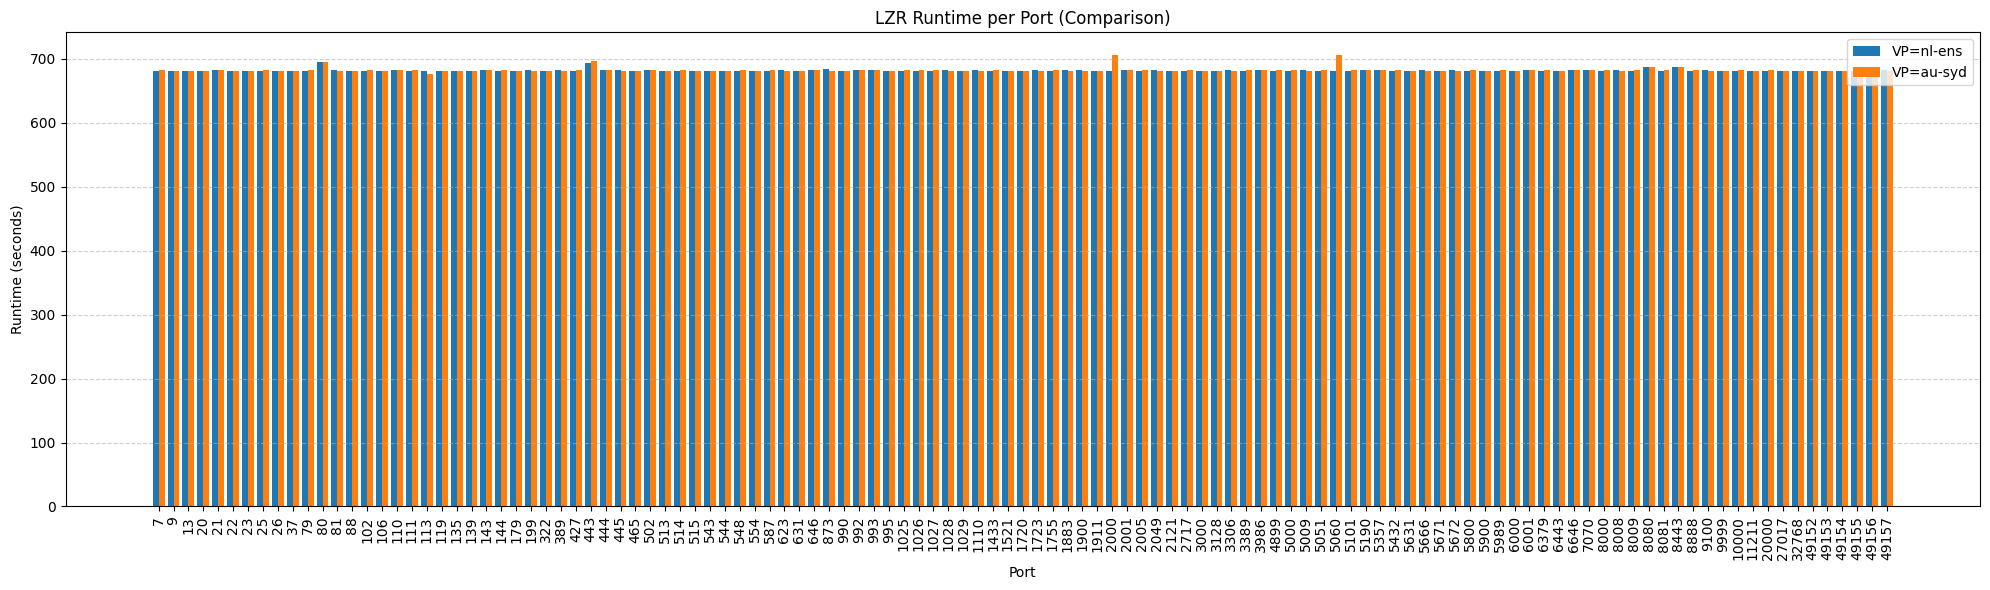

In [7]:
def runtime_to_seconds(runtime):
    minutes = re.search(r"(\d+)m", runtime)
    seconds = re.search(r"([0-9.]+)s", runtime)

    m = int(minutes.group(1)) if minutes else 0
    s = float(seconds.group(1)) if seconds else 0
    return m * 60 + s


# -------- Load files --------
df1 = pd.read_json("../results/lzr/logs/vp=nl-ens/ports_runtime_20260214.jsonl", lines=True)
df2 = pd.read_json("../results/lzr/logs/vp=au-syd/ports_runtime_20260214.jsonl", lines=True)

df1["runtime_seconds_1"] = df1["runtime"].apply(runtime_to_seconds)
df2["runtime_seconds_2"] = df2["runtime"].apply(runtime_to_seconds)

# Keep only relevant columns
df1 = df1[["port", "runtime_seconds_1"]]
df2 = df2[["port", "runtime_seconds_2"]]

# Merge on port
df = pd.merge(df1, df2, on="port")  # inner join; whoever has less ports leads

df = df.sort_values("port")

# -------- Plot --------
x = np.arange(len(df))  # port index positions
width = 0.4             # bar width

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(x - width/2, df["runtime_seconds_1"], width, label="VP=nl-ens")
ax.bar(x + width/2, df["runtime_seconds_2"], width, label="VP=au-syd")

ax.set_xticks(x)
ax.set_xticklabels(df["port"], rotation=90)

ax.set_xlabel("Port")
ax.set_ylabel("Runtime (seconds)")
ax.set_title("LZR Runtime per Port (Comparison)")

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
assert len(df1) == len(df2), f"{len(df1)} vs {len(df2)}"
plt.show()


# Diffs on VPs

## PoPs locations of prefixes that are only visible in one VP

In [33]:
def convert_airport_to_continent_code(airport: str):
    try:
        country = get_country_alpha2_from_airport(airport)
        continent = convert_alpha2_to_continent(country)
        return continent
    except:
        return airport
    
def get_country_alpha2_from_airport(airport: str):
    if airport == "HKX":  # Hong Kong
        return "HK"
    if airport == "DELHI":  # India
        return "IN"
    if airport == "YZD":  # Canada
        return "CA"
    airports_iata = airportsdata.load('IATA')
    try:
        return airports_iata[airport]['country']
    except:
        return airport

def convert_alpha2_to_continent(alpha2: str):
    return convert_continent_code_to_continent_name(
        country_alpha2_to_continent_code(alpha2.upper())
    )

In [34]:
services_only_in_au_airport_cnt_pdf = pd.read_csv("services_only_in_au_airport_cnt.csv")

services_only_in_au_airport_cnt_pdf["continent"] = services_only_in_au_airport_cnt_pdf["airport"].apply(lambda x: convert_airport_to_continent_code(x))

In [35]:
services_only_in_au_airport_cnt_pdf.groupby("continent").size().reset_index(name="count").sort_values(by="count", ascending=False)

,continent,count
4,North America,74
1,Asia,68
2,Europe,68
5,Oceania,42
6,South America,19
0,Africa,13
3,NoCity,4


In [36]:
services_only_in_au_airport_cnt_pdf["country"] = services_only_in_au_airport_cnt_pdf["airport"].apply(lambda x: get_country_alpha2_from_airport(x))

In [37]:
services_only_in_au_airport_cnt_pdf.groupby("country").size().reset_index(name="count").sort_values(by="count", ascending=False)

,country,count
39,US,70
2,AU,35
22,JP,20
34,SG,19
11,DE,17
41,ZA,11
33,SE,10
5,BR,9
12,ES,8
15,GB,8
